In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import uproot

In [ ]:
def load_data(path):
    """
    Load data from a ROOT file.
    """
    data = {}
    with uproot.open(path) as f:
        gens = f["gens/Events"].arrays(library="np")
        jets = f["pfJetsAk5/Events"].arrays(library="np")
        data = {}
        for branch in gens:
            try:
                data[branch] = np.concatenate(gens[branch])
            except ValueError:
                data[branch] = gens[branch]
        for branch in jets:
            try:
                data[branch] = np.concatenate(jets[branch])
            except ValueError:
                data[branch] = jets[branch]
    return data

In [4]:
# with uproot.open("ttbar_all_part_5k.root") as f:
with uproot.open(
    "/storage/agrp/dmitrykl/fastsim/f_delphes/data/full_event/raw_analysis/MonteCarlo2011/Summer11LegDR/TTJets_MSDecays_central_TuneZ2_7TeV-madgraph-tauola/AODSIM/PU_S13_START53_LV6-v1/00000/000F3C2D-E7BA-E311-88FF-90E6BA0D09E8_poet.root"
) as f:
    for key in ["gens/Events", "pfcs/Events"]:
        print(f"Tree: {key} has branches: ")
        for branch in f[key].keys():
            print(f"  - {branch}")

Tree: gens/Events has branches: 
  - numGenPart
  - GenPart_pt
  - GenPart_eta
  - GenPart_mass
  - GenPart_pdgId
  - GenPart_phi
  - GenPart_status
  - GenPart_label
  - GenPart_vx
  - GenPart_vy
  - GenPart_vz
Tree: pfcs/Events has branches: 
  - numPFCand
  - PFCand_pt
  - PFCand_eta
  - PFCand_mass
  - PFCand_pdgId
  - PFCand_phi
  - PFCand_vx
  - PFCand_vy
  - PFCand_vz
  - PFCand_d0
  - PFCand_d0Error
  - PFCand_z0
  - PFCand_z0Error
  - PFCand_ip3d
  - PFCand_ip3dError
  - PFCand_label


In [5]:
# data = load_data('ttbar_label_20k_jets.root')
data = load_data(
    "/storage/agrp/dmitrykl/fastsim/f_delphes/data/full_event/raw_analysis/MonteCarlo2011/Summer11LegDR/TTJets_MSDecays_central_TuneZ2_7TeV-madgraph-tauola/AODSIM/PU_S13_START53_LV6-v1/00000/000F3C2D-E7BA-E311-88FF-90E6BA0D09E8_poet.root"
)

In [6]:
label_map = {
    0: "PileUp",
    1: "Fake",
    2: "Primary",
    3: "FromB",
    4: "FromBC",
    5: "FromC",
    6: "FromTau",
    7: "OtherSecondary",
}

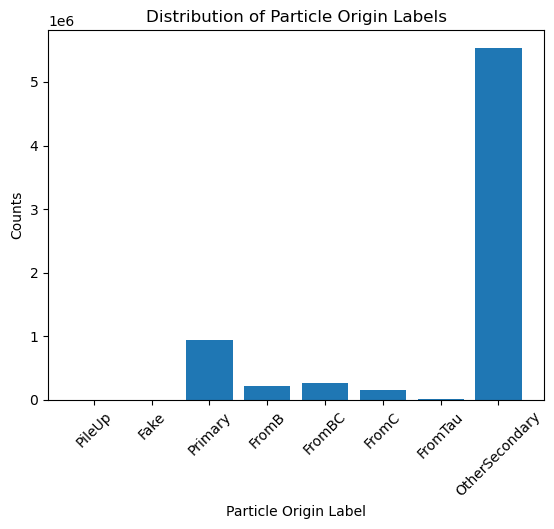

In [7]:
plt.hist(data["GenPart_label"], bins=np.linspace(-0.5, 7.5, 9), rwidth=0.8)
plt.xticks(ticks=np.arange(8), labels=[label_map[i] for i in range(8)], rotation=45)
plt.xlabel("Particle Origin Label")
plt.ylabel("Counts")
plt.title("Distribution of Particle Origin Labels")
plt.show()

In [8]:
num_jets = len(data["jet_flavour"])
print(f"Total number of jets: {num_jets}")
print(f"Average number of jets per event: {num_jets / 20000:.2f}")

Total number of jets: 114947
Average number of jets per event: 5.75


In [9]:
jet_eta = data["jet_eta"]

In [10]:
jets_flavs, jets_counts = np.unique(
    np.abs(data["jet_flavour"][np.abs(jet_eta) < 2.4]), return_counts=True
)

In [11]:
print("Jet flavors distribution:")
print("b-jets count:", jets_counts[jets_flavs == 5][0] if 5 in jets_flavs else 0)
print("c-jets count:", jets_counts[jets_flavs == 4][0] if 4 in jets_flavs else 0)
print("light-jets count:", sum(jets_counts[(jets_flavs != 4) & (jets_flavs != 5)]))

Jet flavors distribution:
b-jets count: 31843
c-jets count: 12055
light-jets count: 60044


In [13]:
jet_mask = (np.abs(data["jet_eta"]) < 2.4) & (data["jet_pt"] > 20)
b_jets_mask = jet_mask & (np.abs(data["jet_flavour"]) == 5)
c_jets_mask = jet_mask & (np.abs(data["jet_flavour"]) == 4)
light_jets_mask = jet_mask & (np.abs(data["jet_flavour"]) != 4) & (np.abs(data["jet_flavour"]) != 5)

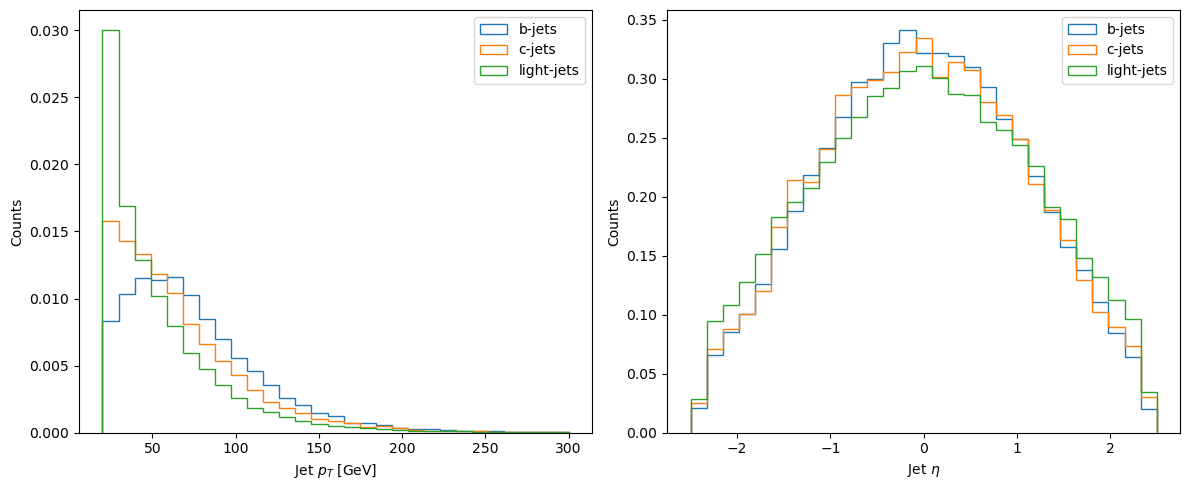

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, (mask, label) in enumerate(
    [
        (b_jets_mask, "b-jets"),
        (c_jets_mask, "c-jets"),
        (light_jets_mask, "light-jets"),
    ]
):
    ax[0].hist(
        data["jet_pt"][mask],
        bins=np.linspace(20, 300, 30),
        label=label,
        histtype="step",
        density=True,
    )
    ax[1].hist(
        data["jet_eta"][mask],
        bins=np.linspace(-2.5, 2.5, 30),
        label=label,
        histtype="step",
        density=True,
    )
ax[0].set_xlabel("Jet $p_T$ [GeV]")
ax[1].set_xlabel("Jet $\eta$")
# ax[0].set_yscale("log")
for i in range(2):
    ax[i].legend()
    ax[i].set_ylabel("Counts")
fig.tight_layout()
plt.show()


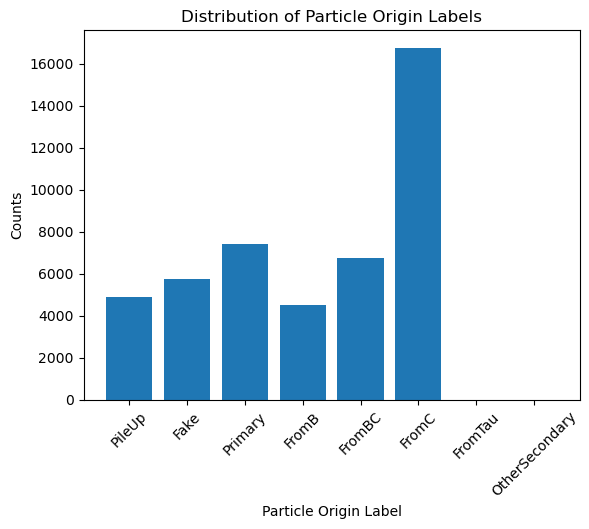

In [12]:
plt.hist(data["jet_flavour"], bins=np.linspace(-0.5, 7.5, 9), rwidth=0.8)
plt.xticks(ticks=np.arange(8), labels=[label_map[i] for i in range(8)], rotation=45)
plt.xlabel("Particle Origin Label")
plt.ylabel("Counts")
plt.title("Distribution of Particle Origin Labels")
plt.show()